In [29]:
# Data presented in the paper [[zhang2024PerformanceInvestigation]]  
# plot them as references

import numpy as np

# 额外给定数据：BLC-max
BLC_max = np.array([
    [0, 298.16],
    [31.30, 299.30],
    [70.31, 300.34],
    [115.61, 301.12],
    [160.61, 301.74],
    [197.32, 302.22],
    [238.62, 302.60],
    [277.63, 302.88],
    [323.52, 303.12],
    [360.23, 303.27],
    [399.24, 303.39],
    [435.95, 303.47],
    [479.54, 303.50],
    [520.84, 303.51],
    [562.14, 303.52],
    [598.85, 303.53],
    [640.15, 303.54],
    [676.86, 303.55],
    [718.16, 303.56],
    [759.46, 303.58],
    [798.47, 303.63],
    [839.77, 303.72],
    [874.19, 303.86],
    [917.78, 304.08],
    [959.08, 304.39],
    [1002.68, 304.83],
    [1039.39, 305.43],
    [1076.10, 306.18],
    [1119.69, 307.10],
    [1158.70, 308.22],
    [1197.71, 309.47],
    [1200.00, 309.74], # I add this one to prevent the out-of-bounds error during interpolation
], dtype=float)
# 额外给定数据：BLC-min
BLC_min = np.array([
    [0, 298.16],
    [39.76, 298.42],
    [81.92, 298.62],
    [121.98, 298.76],
    [157.81, 298.86],
    [197.87, 298.93],
    [240.04, 299.00],
    [286.44, 299.05],
    [320.18, 299.07],
    [358.14, 299.09],
    [402.42, 299.11],
    [438.28, 299.13],
    [478.34, 299.14],
    [520.52, 299.14],
    [558.49, 299.15],
    [604.89, 299.16],
    [649.17, 299.17],
    [678.70, 299.17],
    [720.87, 299.19],
    [763.05, 299.20],
    [798.91, 299.22],
    [843.19, 299.26],
    [883.26, 299.30],
    [923.32, 299.35],
    [961.27, 299.42],
    [995.01, 299.50],
    [1041.39, 299.63],
    [1079.34, 299.78],
    [1121.50, 299.99],
    [1161.54, 300.24],
    [1200, 300.56],
], dtype=float)





In [12]:
from pathlib import Path
import re
import pandas as pd
import os

def read_out_temperature(filename, series_name, data_dir=os.path.join(os.getcwd(), "data")):
    """
    读取本地文件夹中的 .out 文件。
    文件应至少包含两列数值：时间/步数 和 温度值。
    支持空格、Tab、逗号分隔；自动跳过表头和注释行。

    对 Fluent report .out 文件，常见格式为：
        Time Step, report-def, flow-time
    本函数默认取第 1 个数值为横坐标、第 2 个数值为温度。
    """
    path = Path(data_dir) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"未找到 {path}。请确认 {filename} 和这个 notebook/program 放在同一个文件夹，"
            "或手动修改 CFD_DATA_DIR。"
        )

    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "//")):
                continue

            # 提取每一行中的数值，兼容 scientific notation。
            nums = re.findall(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?", line)
            if len(nums) >= 2:
                rows.append([float(nums[0]), float(nums[1])])

    if not rows:
        raise ValueError(f"{path} 中没有读到有效的两列数值数据：time 和 temperature。")

    data = pd.DataFrame(rows, columns=["time_s", "temperature"])
    # Check the values are within the expected range for temperature (e.g., 0-100 °C)
    
    data["temperature"] = data["temperature"] - 273.15  # 转换为摄氏度
    
    if not ((10 <= data["temperature"]).all() and (data["temperature"] <= 100).all()):
        print(f"WARNING: {series_name} is ignored since contains temperature values outside the expected range 10-100 °C. ")
        print(f"Values: min={data['temperature'].min():.2f}, max={data['temperature'].max():.2f}")
        return None    
    
    data.name = series_name
    return data[["time_s", "temperature"]]


def try_read_out_temperature(filename, series_name, data_dir=os.path.join(os.getcwd(), "data")):
    """读取 CFD .out 文件；如果文件不存在则跳过，避免只缺少某一组数据时整段绘图失败。"""
    try:
        data = read_out_temperature(filename, series_name, data_dir=data_dir)
        
        if data is None:
            print(f"WARNING: {series_name} contains no valid data and is ignored.")
            return None
        
        print(f"Loaded {series_name}: {Path(data_dir) / filename}, rows={len(data)}")
        return data
    
    except Exception as exc:
        print(f"WARNING: {exc}")
        return None

In [37]:
def compare_curves_by_stage(
    stage_boundaries,
    stage_names,
    curve_a,
    curve_b,
    time_axis,
    curve_a_name='Curve A',
    curve_b_name='Curve B'
):
    """Compare two curves by stage using max divergence and MSE."""
    curve_a = np.asarray(curve_a)
    curve_b = np.asarray(curve_b)
    time_axis = np.asarray(time_axis)

    if not (len(curve_a) == len(curve_b) == len(time_axis)):
        raise ValueError('curve_a, curve_b, and time_axis must have the same length.')

    diff = curve_a - curve_b
    
    t_stage = [0] + list(stage_boundaries)
    rows = []

    print(f"{curve_a_name}(a) vs. {curve_b_name}(b) comparison for each stage:")
    print(f"{'Stage':<40} {'Time (s)':<20} {'Max_a':<20} {'Max_b':<20} {'Max Divergence (degC)':<30} {'MSE':<20}")

    for i in range(len(t_stage) - 1):
        t_start = t_stage[i]
        t_end = t_stage[i + 1]

        idx_start = np.searchsorted(time_axis, t_start)
        idx_end = np.searchsorted(time_axis, t_end)

        diff_stage = diff[idx_start:idx_end]
        if diff_stage.size == 0:
            continue

        max_divergence = np.max(np.abs(diff_stage))
        mse_stage = np.mean(diff_stage**2)
        max_a = np.max(curve_a[idx_start:idx_end])
        max_b = np.max(curve_b[idx_start:idx_end])
        
        stage_name = stage_names[i] if i < len(stage_names) else f'Stage {i + 1}'
        rows.append({
            'stage': stage_name,
            't_start': t_start,
            't_end': t_end,
            'max_a': max_a,
            'max_b': max_b,
            'max_divergence': max_divergence,
            'mse': mse_stage,
        })

        print(f"{stage_name:<40} {t_start}-{t_end:<20} {max_a:<20.2f} {max_b:<20.2f} {max_divergence:<30.2f} {mse_stage:<20.3g}")

    
    max_divergence_global = np.max(np.abs(diff))
    mse_global = np.mean(diff**2)

    rows.append({
        'stage': 'Global',
        't_start': t_stage[0],
        't_end': t_stage[-1],
        'max_a': np.max(curve_a),
        'max_b': np.max(curve_b),
        'max_divergence': max_divergence_global,
        'mse': mse_global,
    })

    print(f"{'Global':<40} {t_stage[0]}-{t_stage[-1]:<20} {np.max(curve_a):<20.2f} {np.max(curve_b):<20.2f} {max_divergence_global:<30.2f} {mse_global:<20.3g}")

    return (pd.DataFrame(rows),diff)

In [18]:
# load saved calculation results
import os
import sys

PROJECT_ROOT = os.path.abspath("../..")
CASE_ID = "C0017"
CASE_NAME = "C0017R00_ZHANG24_LC_THERM_1D_VAL"

N_bat_seg = 15
N_cool_seg = 20

# load the data frame

file_name = os.path.join(PROJECT_ROOT, "data", CASE_ID, CASE_NAME + ".xlsx")

import pandas as pd
df = pd.read_excel(file_name)

# load the battery temperature and the coolant temperature

T_bat_history = []

for i in range(N_bat_seg):
    T_bat_history.append(df[f"T_Segment_{i+1}"].values[1:])

# Transpose T_bat_history
T_bat_history = np.array(T_bat_history).T

T_cool_history = []
for i in range(N_cool_seg):
    T_cool_history.append(df[f"T_cool_{i+1}"].values[1:])

# Transpose T_cool_history
T_cool_history = np.array(T_cool_history).T

In [25]:
# Data sent by Liu, who find the maximum and minimum temperatures for liquid-cooled BTMS.

CFD_DATA_DIR = os.path.join(PROJECT_ROOT, "data","HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max")

print(f"CFD 数据读取目录: {CFD_DATA_DIR}")

# 要读取并绘制的 CFD 数据文件。
# 新增的两组数据为 min_avg.out 和 max_avg.out，图例分别为 CFD_min_avg 和 CFD_max_avg。
CFD_SERIES_FILES = {
    "CFD_max": "max.out",
    "CFD_min": "min.out",   
    "CFD_max_avg": "max_avg.out",
    "CFD_min_avg": "min_avg.out",
}

# 读取本地 CFD 数据。
cfd_series = {}
for label, filename in CFD_SERIES_FILES.items():
    data = try_read_out_temperature(filename, label, data_dir=CFD_DATA_DIR)
    if data is not None:
        cfd_series[label] = data

CFD 数据读取目录: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max
Loaded CFD_max: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max.out, rows=1201
Loaded CFD_min: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min.out, rows=1201
Loaded CFD_max_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max_avg.out, rows=1201
Loaded CFD_min_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min_avg.out, rows=1201


In [46]:

import numpy as np
from scipy.interpolate import interp1d

num_time_steps = 1200
dt = 1

time_s = np.arange(num_time_steps) * dt

Tmax_1D = np.array([max(T_bat_history[i]) for i in range(num_time_steps)])  # 取每个时间步最后一个电池单元的温度作为 max
# T9_1D = np.array([T_bat_history[i][9] for i in range(num_time_steps)])

Tmin_1D = np.array([T_bat_history[i][5] for i in range(num_time_steps)]) # Liu told me that the 10th battery cell typically has the minimum temperature
# Tmin_1D = np.array([min(T_bat_history[i]) for i in range(num_time_steps)])  

# Use interpolation to smooth the temperature curves and calculate the difference specified curves

BLC_max_interp = interp1d(BLC_max[:, 0], BLC_max[:, 1]-273.15, kind='cubic')
BLC_min_interp = interp1d(BLC_min[:, 0], BLC_min[:, 1]-273.15, kind='cubic')

BLC_max_smooth = BLC_max_interp(time_s)
BLC_min_smooth = BLC_min_interp(time_s)  

cfd_data = cfd_series["CFD_max"]
time_cfd = cfd_data["time_s"]
cfd_max = cfd_data["temperature"]
CFD_max_interp = interp1d(time_cfd, cfd_max, kind='cubic')

cfd_data = cfd_series["CFD_min"]
time_cfd = cfd_data["time_s"]
cfd_min = cfd_data["temperature"]
CFD_min_interp = interp1d(time_cfd, cfd_min, kind='cubic')

CFD_max_smooth = CFD_max_interp(time_s)
CFD_min_smooth = CFD_min_interp(time_s)  

dTmax_1D_BLC = Tmax_1D - BLC_max_smooth
dTmin_1D_BLC = Tmin_1D - BLC_min_smooth

dTmax_CFD_BLC = CFD_max_smooth - BLC_max_smooth
dTmin_CFD_BLC = CFD_min_smooth - BLC_min_smooth

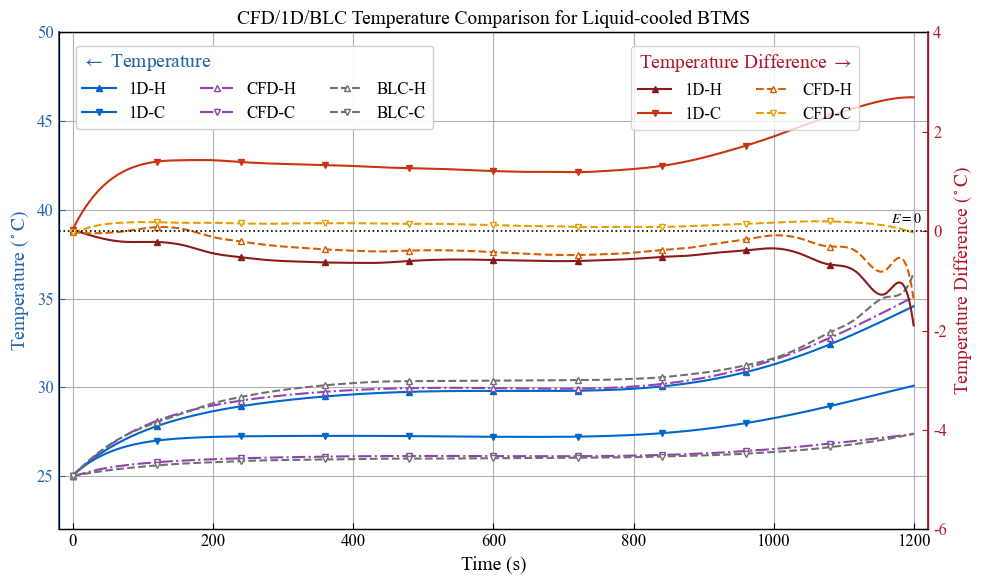

<Figure size 640x480 with 0 Axes>

In [54]:
import matplotlib.pyplot as plt

font_size = 12  # set the font size for the plot

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': font_size,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

plt.figure(figsize=(10, 6))

ax1 = plt.gca()

ax1.set_xlim(-20,1220)
ax1.set_ylim(22, 50)  # set the range of the y-axis for temperature comparison

marker_number = 10
marker_spacing = len(time_s) // marker_number

# Left y-axis: temperature
left_style = {        
    "BLC_MIN": dict(label='BLC-C', color="#707070", ls="--", marker="v",
                    markerfacecolor="white"),
    "BLC_MAX": dict(label='BLC-H', color="#707070", ls="--", marker="^",
                    markerfacecolor="white"),
    "CFD_MIN": dict(label='CFD-C', color="#8E44AD", ls="-.", marker="v",
                    markerfacecolor="white"),    
    "CFD_MAX": dict(label='CFD-H', color="#8E44AD", ls="-.", marker="^",
                    markerfacecolor="white"),
    "1D_MIN":  dict(label='1D-C', color="#0066CC", ls="-", marker="v"),
    "1D_MAX":  dict(label='1D-H', color="#0066CC", ls="-", marker="^"),
}

# Right y-axis: temperature error
right_style = {
    "CFD_MIN": dict(label='CFD-C', color="#E69F00", ls="--", marker="v",
                    markerfacecolor="white"),
    "CFD_MAX": dict(label='CFD-H', color="#D55E00", ls="--", marker="^",
                    markerfacecolor="white"),
    "1D_MIN":  dict(label='1D-C', color="#CC3311", ls="-", marker="v"),
    "1D_MAX":  dict(label='1D-H', color="#8B1A1A", ls="-", marker="^"),
}

left_color = "#2166AC"
right_color = "#B2182B"

line_style = left_style["1D_MAX"]

plt.plot(time_s, Tmax_1D, markersize=5, markevery=marker_spacing, **line_style)

line_style = left_style["1D_MIN"]
plt.plot(time_s, Tmin_1D, markersize=5, markevery=marker_spacing, **line_style)
# plt.plot(time_s, T9_1D, linestyle="--", label="1D-9th")

line_style = left_style["CFD_MAX"]
plt.plot(time_s, CFD_max_smooth, markersize=5, markevery=marker_spacing, **line_style)

line_style = left_style["CFD_MIN"]
plt.plot(time_s, CFD_min_smooth, markersize=5, markevery=marker_spacing, **line_style)

line_style = left_style["BLC_MAX"]
plt.plot(time_s, BLC_max_smooth, markersize=5, markevery=marker_spacing, **line_style)

line_style = left_style["BLC_MIN"]
plt.plot(time_s, BLC_min_smooth, markersize=5, markevery=marker_spacing, **line_style)

ax2 = ax1.twinx()
ax2.set_ylim(-6, 4)  # set the range of the y-axis for temperature error

line_style = right_style["1D_MAX"]
ax2.plot(time_s, dTmax_1D_BLC, markersize=5, markevery=marker_spacing, **line_style)

line_style = right_style["1D_MIN"]
ax2.plot(time_s, dTmin_1D_BLC, markersize=5, markevery=marker_spacing, **line_style)

line_style = right_style["CFD_MAX"]
ax2.plot(time_s, dTmax_CFD_BLC, markersize=5, markevery=marker_spacing, **line_style)

line_style = right_style["CFD_MIN"]
ax2.plot(time_s, dTmin_CFD_BLC, markersize=5, markevery=marker_spacing, **line_style)

ax2.axhline(0, color='black', linestyle=':', linewidth=1.2)  # plot a horizontal line at y=0 for reference  
ax2.annotate(
    r"$E=0$",
    xy=(1.0, 0),
    xycoords=("axes fraction", "data"),
    xytext=(-5, 4),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=font_size-2,
    color="0"
)

ax1.set_xlabel('Time (s)', fontsize=font_size+2)
ax1.set_ylabel(r"Temperature ($^\circ\mathrm{C}$)", color=left_color, fontsize=font_size+2)
ax1.tick_params(axis="y", colors=left_color)
ax1.spines["left"].set_color(left_color)
ax1.spines["left"].set_linewidth(1.3)

ax2.set_ylabel(r"Temperature Difference ($^\circ\mathrm{C}$)", color=right_color, fontsize=font_size+2)
ax2.tick_params(axis="y", colors=right_color)
ax2.spines["right"].set_color(right_color)
ax2.spines["right"].set_linewidth(1.3)

ax1.set_title('CFD/1D/BLC Temperature Comparison for Liquid-cooled BTMS', fontsize=font_size+2)

handles_left, labels_left = ax1.get_legend_handles_labels()

leg1 = ax1.legend(
    handles_left,
    labels_left,
    # title="Temperature - left axis",    
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=3,
    # labelcolor=left_color,
    fontsize=font_size,
    alignment='left'
)
leg1.set_title(r"$\leftarrow$ Temperature", prop={"size": font_size+2})
leg1.get_title().set_color(left_color)

handles_right, labels_right = ax2.get_legend_handles_labels()

leg2 = ax2.legend(
    handles_right,
    labels_right,
    # title="Temperature Difference - right axis",
    # labelcolor=right_color,
    loc="upper right",
    bbox_to_anchor=(0.93, 0.99),
    ncol=2,
    fontsize=font_size,
    alignment='right'
)
leg2.set_title(r"Temperature Difference $\rightarrow$", prop={"size": font_size+2})
leg2.get_title().set_color(right_color)

ax1.add_artist(leg1)

ax1.grid()

plt.tight_layout()

plt.show()

# save the plot as a vector graphic (SVG) and a high-resolution PNG for publication purposes
plot_file_name = os.path.join(PROJECT_ROOT, 'out', CASE_ID, f'{CASE_NAME}.pdf')

if(not os.path.exists(os.path.dirname(plot_file_name))):
    os.makedirs(os.path.dirname(plot_file_name))

plt.savefig(
    plot_file_name,
    dpi=600,
    bbox_inches='tight'
)

# also save one to the paper's working directory

paper_wd = r"D:\Workspace\Paper_eBATS\images"

plt.savefig(
    os.path.join(paper_wd, f'{CASE_NAME}.pdf'),
    dpi=600,
    bbox_inches='tight'
)
